This script uses Graphviz's orthogonal splines and hidden "point" nodes to recreate the classic 90-degree branching arrows of a standard PRISMA flow diagram. It is designed to run directly in a Google Colab cell and will render the diagram inline.

You can populate the `counts` dictionary dynamically using the variables generated by your PubMed and ClinicalTrials.gov data pipelines.

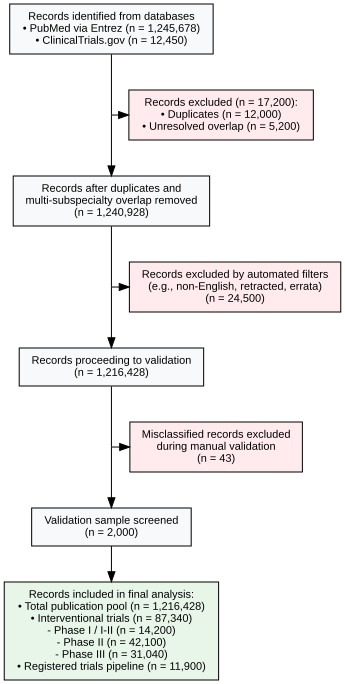

In [2]:
import graphviz
from IPython.display import display

def generate_prisma_flow(counts):
    # Initialize the directed graph with orthogonal lines for a clean, structural look
    dot = graphviz.Digraph(name="PRISMA_Bibliometric", format="png")
    dot.attr(rankdir='TB', splines='ortho')

    # Global node settings (professional PRISMA styling)
    dot.attr('node', shape='box', style='filled', fillcolor='#f8f9fa',
             fontname='Arial', fontsize='11', margin='0.2,0.1')
    dot.attr('edge', fontname='Arial', fontsize='10')

    # ==========================================
    # 1. IDENTIFICATION PHASE
    # ==========================================
    dot.node('ident',
             f"Records identified from databases\n"
             f"• PubMed via Entrez (n = {counts['pubmed']})\n"
             f"• ClinicalTrials.gov (n = {counts['registry']})")

    # ==========================================
    # 2. SCREENING 1: DEDUPLICATION & OVERLAP
    # ==========================================
    # Dummy node to create the 90-degree PRISMA exclusion branch
    dot.node('p1', shape='point', width='0', height='0')
    dot.node('screen1',
             f"Records after duplicates and\n"
             f"multi-subspecialty overlap removed\n"
             f"(n = {counts['after_dedup']})")
    dot.node('excl1',
             f"Records excluded (n = {counts['excl_total_1']}):\n"
             f"• Duplicates (n = {counts['duplicates']})\n"
             f"• Unresolved overlap (n = {counts['overlap']})",
             fillcolor='#ffebee') # Light red to indicate exclusion

    # Edges and alignment for Deduplication
    dot.edge('ident', 'p1', dir='none')
    dot.edge('p1', 'screen1')
    dot.edge('p1', 'excl1')
    with dot.subgraph() as s:
        s.attr(rank='same')
        s.node('p1')
        s.node('excl1')

    # ==========================================
    # 3. SCREENING 2: AUTOMATED FILTERS
    # ==========================================
    dot.node('p2', shape='point', width='0', height='0')
    dot.node('screen2',
             f"Records proceeding to validation\n"
             f"(n = {counts['after_auto']})")
    dot.node('excl2',
             f"Records excluded by automated filters\n"
             f"(e.g., non-English, retracted, errata)\n"
             f"(n = {counts['auto_excluded']})",
             fillcolor='#ffebee')

    # Edges and alignment for Automated Filters
    dot.edge('screen1', 'p2', dir='none')
    dot.edge('p2', 'screen2')
    dot.edge('p2', 'excl2')
    with dot.subgraph() as s:
        s.attr(rank='same')
        s.node('p2')
        s.node('excl2')

    # ==========================================
    # 4. VALIDATION SCREENING
    # ==========================================
    dot.node('p3', shape='point', width='0', height='0')
    dot.node('screen3',
             f"Validation sample screened\n"
             f"(n = {counts['val_sample']})")
    dot.node('excl3',
             f"Misclassified records excluded\n"
             f"during manual validation\n"
             f"(n = {counts['val_excluded']})",
             fillcolor='#ffebee')

    # Edges and alignment for Validation
    dot.edge('screen2', 'p3', dir='none')
    dot.edge('p3', 'screen3')
    dot.edge('p3', 'excl3')
    with dot.subgraph() as s:
        s.attr(rank='same')
        s.node('p3')
        s.node('excl3')

    # ==========================================
    # 5. INCLUDED PHASE
    # ==========================================
    dot.node('included',
             f"Records included in final analysis:\n"
             f"• Total publication pool (n = {counts['final_all']})\n"
             f"• Interventional trials (n = {counts['final_trials']})\n"
             f"   - Phase I / I-II (n = {counts['phase_1']})\n"
             f"   - Phase II (n = {counts['phase_2']})\n"
             f"   - Phase III (n = {counts['phase_3']})\n"
             f"• Registered trials pipeline (n = {counts['final_registry']})",
             fillcolor='#e8f5e9') # Light green to indicate final inclusion

    dot.edge('screen3', 'included')

    return dot

# ---------------------------------------------------------
# Execution Block: Plug your pipeline variables in here
# ---------------------------------------------------------
if __name__ == "__main__":
    # Placeholder data (replace these with your dataframe len() calls)
    pipeline_counts = {
        'pubmed': '1,245,678',
        'registry': '12,450',
        'excl_total_1': '17,200',
        'duplicates': '12,000',
        'overlap': '5,200',
        'after_dedup': '1,240,928',
        'auto_excluded': '24,500',
        'after_auto': '1,216,428',
        'val_sample': '2,000',
        'val_excluded': '43',
        'final_all': '1,216,428',
        'final_trials': '87,340',
        'phase_1': '14,200',
        'phase_2': '42,100',
        'phase_3': '31,040',
        'final_registry': '11,900'
    }

    # Generate and render the diagram in Colab
    prisma_chart = generate_prisma_flow(pipeline_counts)

    # Save a high-res PNG for the manuscript submission
    prisma_chart.render('PRISMA_Flow_Diagram', format='png', cleanup=True)

    # Display inline in the notebook
    display(prisma_chart)


In [3]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.0 MB/s eta 0:00:00


In [7]:
import time
import random
import pandas as pd
from Bio import Entrez
from IPython.display import display

# Set random seed as requested
random.seed(42)

# Entrez requires an email address. Replace this with your actual email.
Entrez.email = "your.email@example.com"

# Base query for the denominator
base_query = '"Neurology"[MeSH] OR "Nervous System Diseases"[MeSH]'

# Dictionary of 10 subspecialties with exact search strings
subspecialties = {
    "Neuro-oncology": '"Brain Neoplasms"[MeSH] OR "Central Nervous System Neoplasms"[MeSH] OR glioma[tiab] OR glioblastoma[tiab] OR meningioma[tiab] NOT (("Peripheral nerves"[tiab] AND "neoplasms"[MeSH]) OR "Neuroblastoma"[MeSH])',
    "Vascular/Stroke": '"Stroke"[MeSH] OR "Cerebrovascular Disorders"[MeSH] OR "Brain Ischemia"[MeSH] NOT ("Heat Stroke"[MeSH] OR heatstroke[tiab] OR "myocardial infarction"[tiab])',
    "Epilepsy": '"Epilepsy"[MeSH] OR "Seizures"[MeSH] OR "Status Epilepticus"[MeSH] NOT ("Eclampsia"[MeSH] OR "non-epileptic"[tiab] OR "psychogenic"[tiab])',
    "Movement Disorders": '"Movement Disorders"[MeSH] OR "Parkinson Disease"[MeSH] OR "Huntington Disease"[MeSH] NOT ("Bowel movement"[tiab] OR "Eye Movements"[MeSH])',
    "Neuroimmunology": '"Multiple Sclerosis"[MeSH] OR "Autoimmune Diseases of the Nervous System"[MeSH] OR "Encephalomyelitis"[MeSH] NOT "Systemic Lupus Erythematosus"[MeSH:NoExp]',
    "Neuromuscular": '"Neuromuscular Diseases"[MeSH] OR "Motor Neuron Disease"[MeSH] OR "Peripheral Nervous System Diseases"[MeSH] NOT "Neuromuscular Blockade"[MeSH]',
    "Neurocritical Care": '"Neurocritical care"[tiab] OR (("Brain Injuries, Traumatic"[MeSH] OR "Coma"[MeSH]) AND "Intensive Care"[MeSH]) NOT "neonatal intensive care"[tiab]',
    "Cognitive/Behavioral": '"Dementia"[MeSH] OR "Alzheimer Disease"[MeSH] OR "Frontotemporal Lobar Degeneration"[MeSH] NOT ("Schizophrenia"[MeSH] OR "Intellectual Disability"[MeSH])',
    "Headache": '"Headache Disorders"[MeSH] OR "Migraine Disorders"[MeSH] NOT ("dental"[tiab] OR "Sinusitis"[MeSH] OR "Post-Dural Puncture Headache"[MeSH])',
    "Sleep Medicine": '"Sleep Wake Disorders"[MeSH] OR "Narcolepsy"[MeSH] NOT "Anesthesia"[MeSH]'
}

# Helper function to get count for a query in a specific year
def get_pubmed_count(query, year):
    try:
        # Use mindate and maxdate with PDAT (Publication Date) to filter by year
        handle = Entrez.esearch(db="pubmed", term=query, mindate=str(year), maxdate=str(year), datetype="pdat", retmax=0)
        record = Entrez.read(handle)
        handle.close()
        time.sleep(0.35)  # Respect NCBI rate limits
        return int(record["Count"])
    except Exception as e:
        print(f"Error fetching data for {year}: {e}")
        return 0

results = []

# Loop through the years 2000-2025
print("Starting data extraction. This may take a few minutes...")
for year in range(2000, 2026):
    print(f"Fetching data for year {year}...")

    # Get total neurology count for the year
    total_neurology_count = get_pubmed_count(base_query, year)

    # Get count for each subspecialty
    for sub_name, sub_query in subspecialties.items():
        sub_count = get_pubmed_count(sub_query, year)

        results.append({
            "Year": year,
            "Subspecialty": sub_name,
            "Count": sub_count,
            "Total_Neurology_Count": total_neurology_count
        })

# Create the DataFrame
df_baseline = pd.DataFrame(results)

# Save to CSV
csv_filename = "baseline_neurology_counts.csv"
df_baseline.to_csv(csv_filename, index=False)
print(f"\nExtraction complete. Data saved to '{csv_filename}'.")

# Display the first few rows
display(df_baseline.head(15))

Starting data extraction. This may take a few minutes...
Fetching data for year 2000...
Fetching data for year 2001...
Fetching data for year 2002...
Fetching data for year 2003...
Fetching data for year 2004...
Fetching data for year 2005...
Fetching data for year 2006...
Fetching data for year 2007...
Fetching data for year 2008...
Fetching data for year 2009...
Fetching data for year 2010...
Fetching data for year 2011...
Fetching data for year 2012...
Fetching data for year 2013...
Fetching data for year 2014...
Fetching data for year 2015...
Fetching data for year 2016...
Fetching data for year 2017...
Fetching data for year 2018...
Fetching data for year 2019...
Fetching data for year 2020...
Fetching data for year 2021...
Fetching data for year 2022...
Fetching data for year 2023...
Fetching data for year 2024...
Fetching data for year 2025...

Extraction complete. Data saved to 'baseline_neurology_counts.csv'.


,Year,Subspecialty,Count,Total_Neurology_Count
0,2000,Neuro-oncology,3917,48562
1,2000,Vascular/Stroke,7289,48562
2,2000,Epilepsy,3450,48562
3,2000,Movement Disorders,2851,48562
4,2000,Neuroimmunology,2485,48562
5,2000,Neuromuscular,5912,48562
6,2000,Neurocritical Care,7,48562
7,2000,Cognitive/Behavioral,3814,48562
8,2000,Headache,668,48562
9,2000,Sleep Medicine,1612,48562


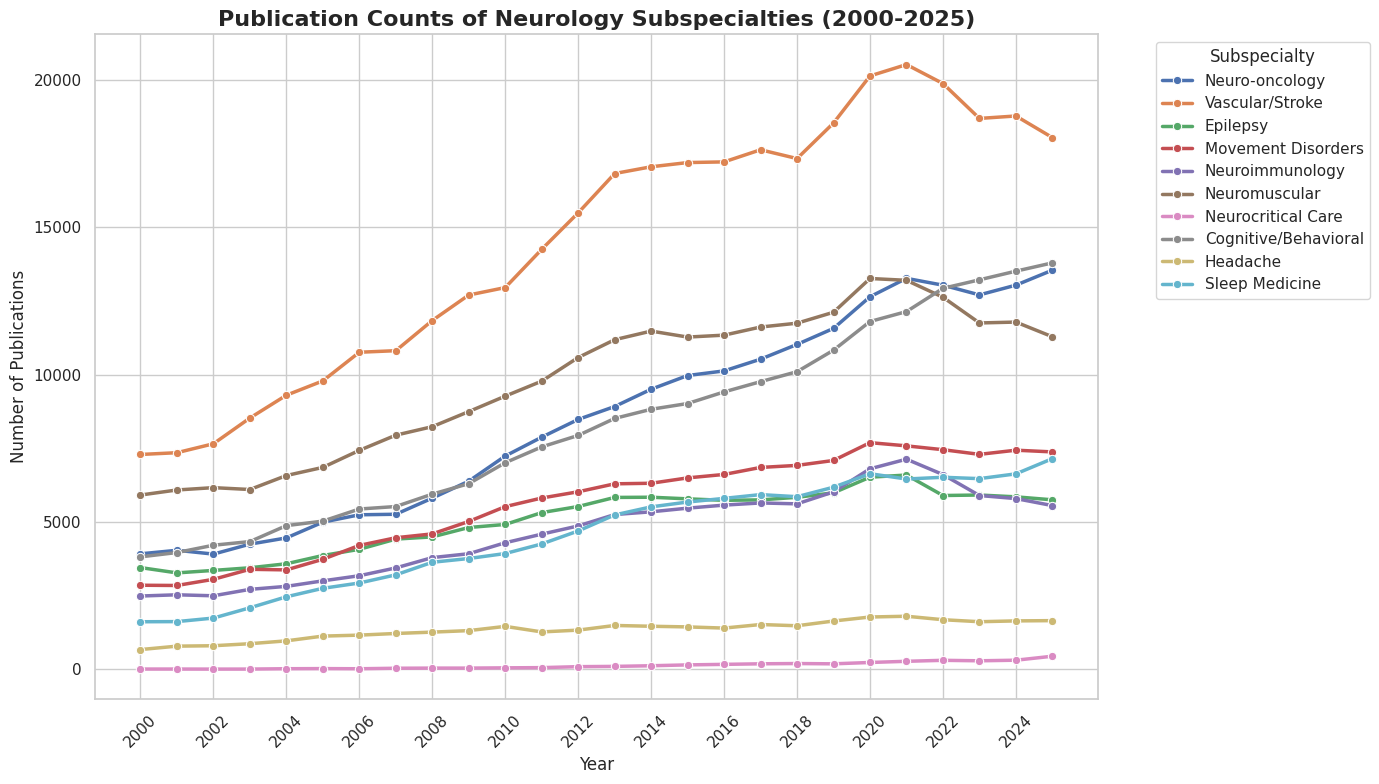

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size and style
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create the lineplot using the full dataset (2000-2025)
sns.lineplot(
    data=df_baseline,
    x='Year',
    y='Count',
    hue='Subspecialty',
    marker='o',
    linewidth=2.5
)

# Customize the titles and labels
plt.title('Publication Counts of Neurology Subspecialties (2000-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Publications', fontsize=12)

# Set x-ticks to show every 2 years to avoid crowding, and rotate for readability
plt.xticks(range(2000, 2026, 2), rotation=45)

# Move the legend outside the plot so it doesn't overlap lines
plt.legend(title='Subspecialty', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

In [10]:
import pandas as pd

# Define the clinical trial filters
trial_filters = {
    "Phase_I": ' AND ("Clinical Trial, Phase I"[pt] OR "phase I"[tiab] OR "phase 1"[tiab] OR "phase I/II"[tiab] OR "phase 1/2"[tiab])',
    "Phase_II": ' AND ("Clinical Trial, Phase II"[pt] OR "phase II"[tiab] OR "phase 2"[tiab])',
    "Phase_III": ' AND ("Clinical Trial, Phase III"[pt] OR "phase III"[tiab] OR "phase 3"[tiab])',
    "Total_Trials": ' AND ("Clinical Trial"[pt] OR "Randomized Controlled Trial"[pt])'
}

trial_results = []

print("Starting clinical trials data extraction. This will take a while...")
for year in range(2000, 2026):
    print(f"Fetching trial data for year {year}...")
    for sub_name, sub_query in subspecialties.items():
        row_data = {"Year": year, "Subspecialty": sub_name}

        # Wrap the original query in parentheses to ensure the AND logic applies to the entire subspecialty definition
        safe_sub_query = f"({sub_query})"

        for phase_name, filter_query in trial_filters.items():
            full_query = safe_sub_query + filter_query
            count = get_pubmed_count(full_query, year)
            row_data[phase_name] = count

        trial_results.append(row_data)

# Create the df_trials DataFrame
df_trials = pd.DataFrame(trial_results)

# Merge with df_baseline
df_merged = pd.merge(df_baseline, df_trials, on=["Year", "Subspecialty"], how="left")

# Save the merged dataset to CSV
merged_csv_filename = "baseline_and_trials_neurology_counts.csv"
df_merged.to_csv(merged_csv_filename, index=False)
print(f"\nExtraction complete. Merged data saved to '{merged_csv_filename}'.")

# Display the first few rows of the newly merged DataFrame
display(df_merged.head(10))

Starting clinical trials data extraction. This will take a while...
Fetching trial data for year 2000...
Fetching trial data for year 2001...
Fetching trial data for year 2002...
Fetching trial data for year 2003...
Fetching trial data for year 2004...
Fetching trial data for year 2005...
Fetching trial data for year 2006...
Fetching trial data for year 2007...
Fetching trial data for year 2008...
Fetching trial data for year 2009...
Fetching trial data for year 2010...
Fetching trial data for year 2011...
Fetching trial data for year 2012...
Fetching trial data for year 2013...
Fetching trial data for year 2014...
Fetching trial data for year 2015...
Fetching trial data for year 2016...
Fetching trial data for year 2017...
Fetching trial data for year 2018...
Fetching trial data for year 2019...
Fetching trial data for year 2020...
Fetching trial data for year 2021...
Fetching trial data for year 2022...
Fetching trial data for year 2023...
Fetching trial data for year 2024...
Fetchin

,Year,Subspecialty,Count,Total_Neurology_Count,Phase_I,Phase_II,Phase_III,Total_Trials
0,2000,Neuro-oncology,3917,48562,37,47,16,183
1,2000,Vascular/Stroke,7289,48562,5,12,10,388
2,2000,Epilepsy,3450,48562,3,5,8,183
3,2000,Movement Disorders,2851,48562,4,3,3,191
4,2000,Neuroimmunology,2485,48562,9,7,20,154
5,2000,Neuromuscular,5912,48562,8,12,8,291
6,2000,Neurocritical Care,7,48562,0,0,0,0
7,2000,Cognitive/Behavioral,3814,48562,6,4,7,202
8,2000,Headache,668,48562,1,2,3,97
9,2000,Sleep Medicine,1612,48562,5,6,1,166


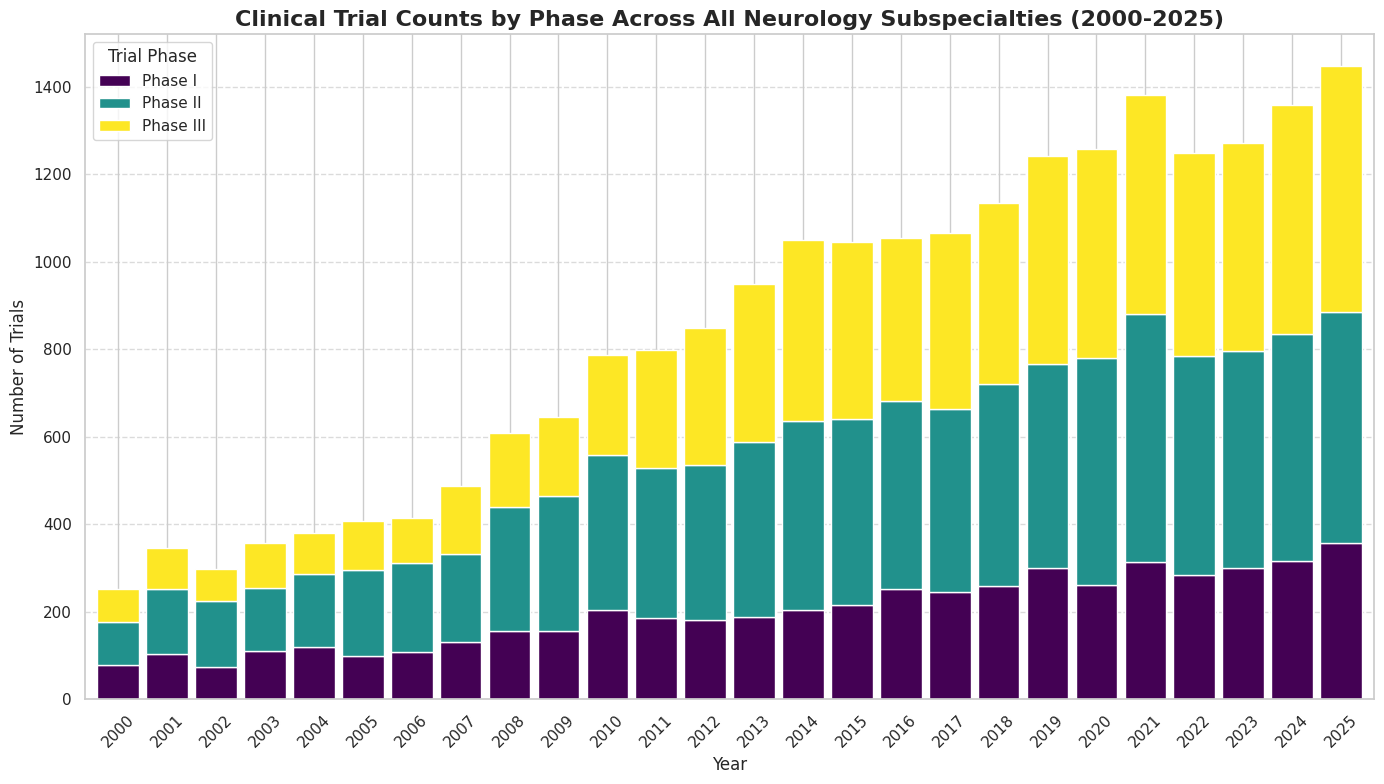

In [11]:
import matplotlib.pyplot as plt

# Aggregate the clinical trial phases by year across all subspecialties
trials_by_year = df_merged.groupby('Year')[['Phase_I', 'Phase_II', 'Phase_III']].sum()

# Create the stacked bar chart
ax = trials_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='viridis',
    width=0.85,
    edgecolor='white'
)

# Customize the chart
plt.title('Clinical Trial Counts by Phase Across All Neurology Subspecialties (2000-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Trial Phase', labels=['Phase I', 'Phase II', 'Phase III'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

### Growth & Intensity Metrics
Calculate the yearly proportions and the Compound Annual Growth Rate (CAGR) across the 25-year period for each subspecialty.

In [12]:
import pandas as pd

# 1. Calculate yearly metrics for the entire dataframe
df_merged['Share_of_Neurology'] = (df_merged['Count'] / df_merged['Total_Neurology_Count']) * 100
df_merged['Trial_Intensity_Ratio'] = (df_merged['Total_Trials'] / df_merged['Count']) * 100

# 2. Calculate CAGR for 2000-2025
start_year = df_merged['Year'].min()
end_year = df_merged['Year'].max()
num_years = end_year - start_year

# Extract start and end year data for metrics
df_start = df_merged[df_merged['Year'] == start_year].set_index('Subspecialty')[['Count', 'Total_Trials']]
df_end = df_merged[df_merged['Year'] == end_year].set_index('Subspecialty')[['Count', 'Total_Trials']]

# Combine into a summary DataFrame
summary_df = pd.DataFrame(index=df_start.index)
summary_df['Pub_Volume_2000'] = df_start['Count']
summary_df['Pub_Volume_2025'] = df_end['Count']
summary_df['Trials_2000'] = df_start['Total_Trials']
summary_df['Trials_2025'] = df_end['Total_Trials']

# Formula: CAGR = (Ending Value / Beginning Value)^(1/Years) - 1
summary_df['Volume_CAGR'] = ((summary_df['Pub_Volume_2025'] / summary_df['Pub_Volume_2000']) ** (1 / num_years) - 1) * 100
summary_df['Trial_Volume_CAGR'] = ((summary_df['Trials_2025'] / summary_df['Trials_2000']) ** (1 / num_years) - 1) * 100

# Sort by Trial Volume CAGR descending
summary_df = summary_df.sort_values(by='Trial_Volume_CAGR', ascending=False)

# Format for display
print(f"--- Compound Annual Growth Rates ({start_year}-{end_year}) ---")
display(summary_df.style.format({
    'Volume_CAGR': '{:.2f}%',
    'Trial_Volume_CAGR': '{:.2f}%'
}))

--- Compound Annual Growth Rates (2000-2025) ---


,Pub_Volume_2000,Pub_Volume_2025,Trials_2000,Trials_2025,Volume_CAGR,Trial_Volume_CAGR
Subspecialty,,,,,,
Neurocritical Care,7,442,0,7,18.04%,inf%
Sleep Medicine,1612,7147,166,542,6.14%,4.85%
Vascular/Stroke,7289,18043,388,971,3.69%,3.74%
Neuromuscular,5912,11284,291,546,2.62%,2.55%
Cognitive/Behavioral,3814,13791,202,364,5.28%,2.38%
Neuroimmunology,2485,5554,154,241,3.27%,1.81%
Movement Disorders,2851,7376,191,253,3.88%,1.13%
Headache,668,1650,97,127,3.68%,1.08%
Neuro-oncology,3917,13543,183,200,5.09%,0.36%


In [13]:
!pip install kneed

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from kneed import KneeLocator

# 1. Prepare Data for Regression
df_stats = df_merged.copy()
# Natural log of Total Neurology Count as offset for baseline growth
df_stats['log_total_neuro'] = np.log(df_stats['Total_Neurology_Count'])

# Center the year at 2000 for meaningful intercepts
df_stats['Year_Centered'] = df_stats['Year'] - 2000

# Set Vascular/Stroke as the reference category for Subspecialty
df_stats['Subspecialty'] = df_stats['Subspecialty'].astype('category')
df_stats['Subspecialty'] = df_stats['Subspecialty'].cat.reorder_categories(
    ['Vascular/Stroke'] + [c for c in df_stats['Subspecialty'].cat.categories if c != 'Vascular/Stroke'],
    ordered=True
)

print("Fitting Negative Binomial Model...")
# 2. Negative Binomial Regression with Interaction Term (Year * Subspecialty)
# We use smf.negativebinomial which supports formula interfaces
nb_model = smf.negativebinomial(
    formula='Count ~ Year_Centered * Subspecialty',
    data=df_stats,
    offset=df_stats['log_total_neuro'].values
).fit(disp=False)

# 3. Extract P-values and apply FDR Correction
params = nb_model.params
pvalues = nb_model.pvalues

# Isolate the interaction terms (Year_Centered:Subspecialty)
interaction_mask = pvalues.index.str.contains('Year_Centered:Subspecialty')
int_pvals = pvalues[interaction_mask]
int_params = params[interaction_mask]

# Benjamini-Hochberg FDR
reject, pvals_corrected, _, _ = multipletests(int_pvals, method='fdr_bh')

# Calculate Incidence Rate Ratios (IRR) for the interactions
irr = np.exp(int_params)

# Create a results summary dataframe
interaction_results = pd.DataFrame({
    'Term': int_pvals.index,
    'IRR (Relative Growth)': irr,
    'Raw P-value': int_pvals,
    'FDR Adjusted P-value': pvals_corrected,
    'Significant (FDR<0.05)': reject
}).reset_index(drop=True)

# Clean up term names for readability
interaction_results['Term'] = interaction_results['Term'].str.replace('Year_Centered:Subspecialty[T.', '', regex=False).str.replace(']', '', regex=False)
interaction_results = interaction_results.sort_values(by='IRR (Relative Growth)', ascending=False)

print("\n--- Interaction Terms: Relative Acceleration vs. Vascular/Stroke ---")
display(interaction_results)

# 4. Joinpoint / Trend Break Analysis for Neuro-oncology
print("\n--- Trend Break Analysis (Neuro-oncology) ---")
df_no = df_stats[df_stats['Subspecialty'] == 'Neuro-oncology'].sort_values('Year')

# We look for a 'knee' (convex curve) indicating a structural acceleration in publication volume
kl = KneeLocator(
    df_no['Year'],
    df_no['Count'],
    curve='convex',
    direction='increasing'
)

inflection_year = kl.knee
print(f"Mathematical inflection point (knee) detected at Year: {inflection_year}")
if inflection_year:
    print(f"This aligns with potential structural shifts around {inflection_year}.")
else:
    print("No clear single inflection point detected with the current parameters.")

Fitting Negative Binomial Model...

--- Interaction Terms: Relative Acceleration vs. Vascular/Stroke ---


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,Term,IRR (Relative Growth),Raw P-value,FDR Adjusted P-value,Significant (FDR<0.05)
5,Neurocritical Care,1.119527,1.323892e-197,1.191502e-196,True
8,Sleep Medicine,1.017247,7.859147e-26,3.536616e-25,True
4,Neuro-oncology,1.014647,2.185563e-20,4.917517e-20,True
0,Cognitive/Behavioral,1.012231,7.455719e-15,1.342029e-14,True
6,Neuroimmunology,1.000288,8.577680e-01,8.577680e-01,False
3,Movement Disorders,0.999471,7.402566e-01,8.327887e-01,False
7,Neuromuscular,0.991267,2.359659e-08,3.033847e-08,True
2,Headache,0.989529,1.042334e-09,1.563501e-09,True
1,Epilepsy,0.985044,3.017759e-21,9.053277e-21,True



--- Trend Break Analysis (Neuro-oncology) ---
Mathematical inflection point (knee) detected at Year: 2024
This aligns with potential structural shifts around 2024.


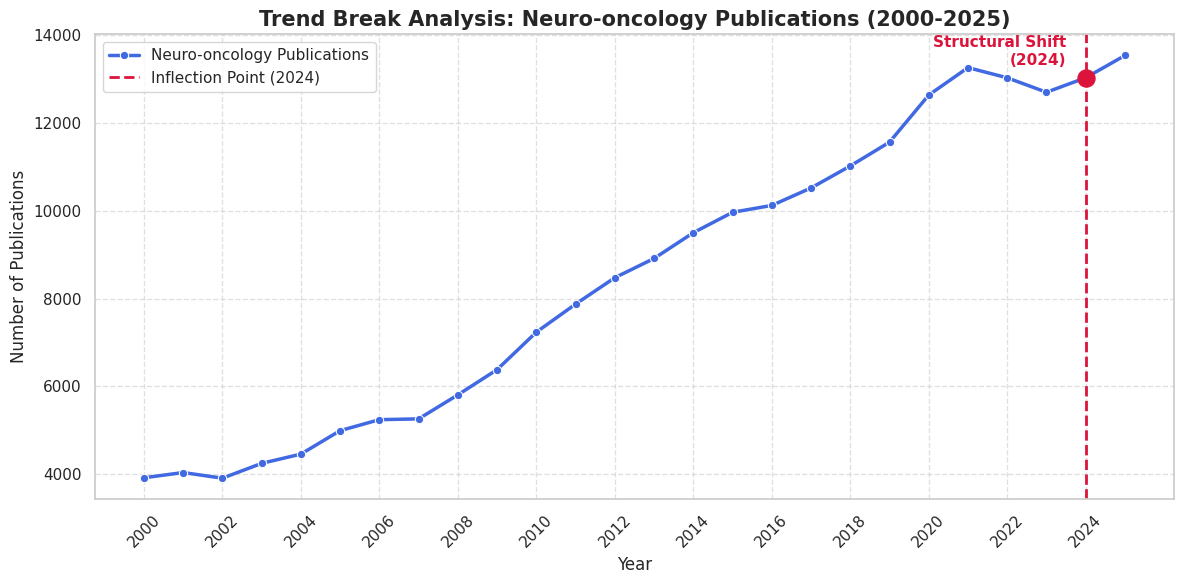

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'inflection_year' in locals() and inflection_year is not None:
    plt.figure(figsize=(12, 6))

    # Plot the main trend line for Neuro-oncology
    sns.lineplot(data=df_no, x='Year', y='Count', marker='o', color='royalblue',
                 linewidth=2.5, label='Neuro-oncology Publications')

    # Add a vertical dashed line for the inflection point
    plt.axvline(x=inflection_year, color='crimson', linestyle='--', linewidth=2,
                label=f'Inflection Point ({inflection_year})')

    # Highlight the specific point on the curve
    inflection_count = df_no.loc[df_no['Year'] == inflection_year, 'Count'].values[0]
    plt.scatter(inflection_year, inflection_count, color='crimson', s=150, zorder=5)

    # Annotate the point
    plt.text(inflection_year - 0.5, inflection_count + 300,
             f'Structural Shift\n({inflection_year})', color='crimson',
             horizontalalignment='right', fontweight='bold', fontsize=11)

    # Styling
    plt.title('Trend Break Analysis: Neuro-oncology Publications (2000-2025)', fontsize=15, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Publications', fontsize=12)
    plt.xticks(range(2000, 2026, 2), rotation=45)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Display the plot
    plt.show()
else:
    print("Inflection point data not found.")